# 📅 Seasonal Performance Analysis

**Goal**: Analyze how athlete performance evolves throughout a calendar year. Identify peaks, seasonal trends (Indoor vs. Outdoor), and visualize the "heartbeat" of the athletics season.

In [2]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.linear_model import LinearRegression

# Add project root to path to import util and plotting modules
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import util
import plotting.plotting_style as plt
from plotting.plotting_style import rgb
import plotting.plotting_style


# Load the data
# df = util.load_data()
df = util.load_data(path_file='/Users/maxwernz/development/Data Literacy/data_csv/final_Data_iaaf_scores_neu_v2.csv') 
df
# df.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score,group
0,2017,W,Frauen,100 m,10.95,1.3,Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211,Sprint
1,2017,W,Frauen,100 m,11.06,1.8,Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187,Sprint
2,2017,W,Frauen,100 m,11.14,-0.2,Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169,Sprint
3,2017,W,Frauen,100 m,11.24,0.3,Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148,Sprint
4,2017,W,Frauen,100 m,11.25,1.9,Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146,Sprint
...,...,...,...,...,...,...,...,...,...,...,...,...,...
238025,2025,M,Maenner,Speerwurf,62.47,NaN,Sebastian Knorn,2005,Werdener Turnerbund,15.06.2025,Dortmund-Hacheney,853,Throw
238026,2025,M,Maenner,Speerwurf,62.44,NaN,Amadeus Graeber,2005,Eintracht Frankfurt,18.05.2025,Franconville (FRA),853,Throw
238027,2025,M,Maenner,Speerwurf,62.04,NaN,Fiete Wauer,2007,LC Cottbus,14.05.2025,Cottbus,847,Throw
238028,2025,M,Maenner,Speerwurf,61.98,NaN,Anton Steffen,2007,1. LAV Rostock,11.07.2025,Bochum-Wattenscheid,846,Throw


## 1. Date Preprocessing
The `datum` column contains mixed formats (e.g., "05.08." without year, or "29.04.2023" with year). We need to parse this into a proper datetime object and extract the **Day of Year (1-366)**.

In [3]:
def parse_german_date(row):
    date_str = row['datum']
    year_col = row['jahr']
    
    if pd.isna(date_str):
        return pd.NaT
    
    date_str = str(date_str).strip()
    
    # Attempt 1: Full date format "dd.mm.yyyy"
    try:
        return pd.to_datetime(date_str, format='%d.%m.%Y')
    except ValueError:
        pass
    
    # Attempt 2: Short format "dd.mm." (year is missing, take from 'jahr' col)
    try:
        # Remove trailing dot if present
        clean_str = date_str.rstrip('.')
        # Parse as day.month
        temp_date = pd.to_datetime(clean_str, format='%d.%m')
        # Replace the default 1900 year with the actual year from the dataset
        return temp_date.replace(year=int(year_col))
    except ValueError:
        return pd.NaT

# Apply the parser (this might take a moment)
print("Parsing dates...")
df['parsed_date'] = df.apply(parse_german_date, axis=1)

# Drop rows where date parsing failed
df_clean = df.dropna(subset=['parsed_date']).copy()

# Extract 'Day of Year' for seasonality comparison
df_clean['day_of_year'] = df_clean['parsed_date'].dt.dayofyear

print(f"Successfully parsed {len(df_clean)} / {len(df)} dates.")
df_clean[['datum', 'jahr', 'parsed_date', 'day_of_year']].head()

Parsing dates...


/var/folders/lf/d2nc392142b837mf8sypzlx00000gn/T/ipykernel_7731/929509185.py:21: DeprecationWarning: Parsing dates involving a day of month without a year specified is ambiguous
and fails to parse leap day. The default behavior will change in Python 3.15
to either always raise an exception or to use a different default year (TBD).
To avoid trouble, add a specific year to the input & format.
See https://github.com/python/cpython/issues/70647.
  temp_date = pd.to_datetime(clean_str, format='%d.%m')


Successfully parsed 160135 / 160141 dates.


,datum,jahr,parsed_date,day_of_year
0,05.08.,2017,2017-08-05,217
1,25.05.,2017,2017-05-25,145
2,27.08.,2017,2017-08-27,239
3,15.07.,2017,2017-07-15,196
4,11.06.,2017,2017-06-11,162


## 2. Single Year Analysis (e.g., 2019)
Let's look at a single, pre-pandemic year to understand the typical structure.
We calculate the **daily mean IAAF score** to see when the "best" performances happen.

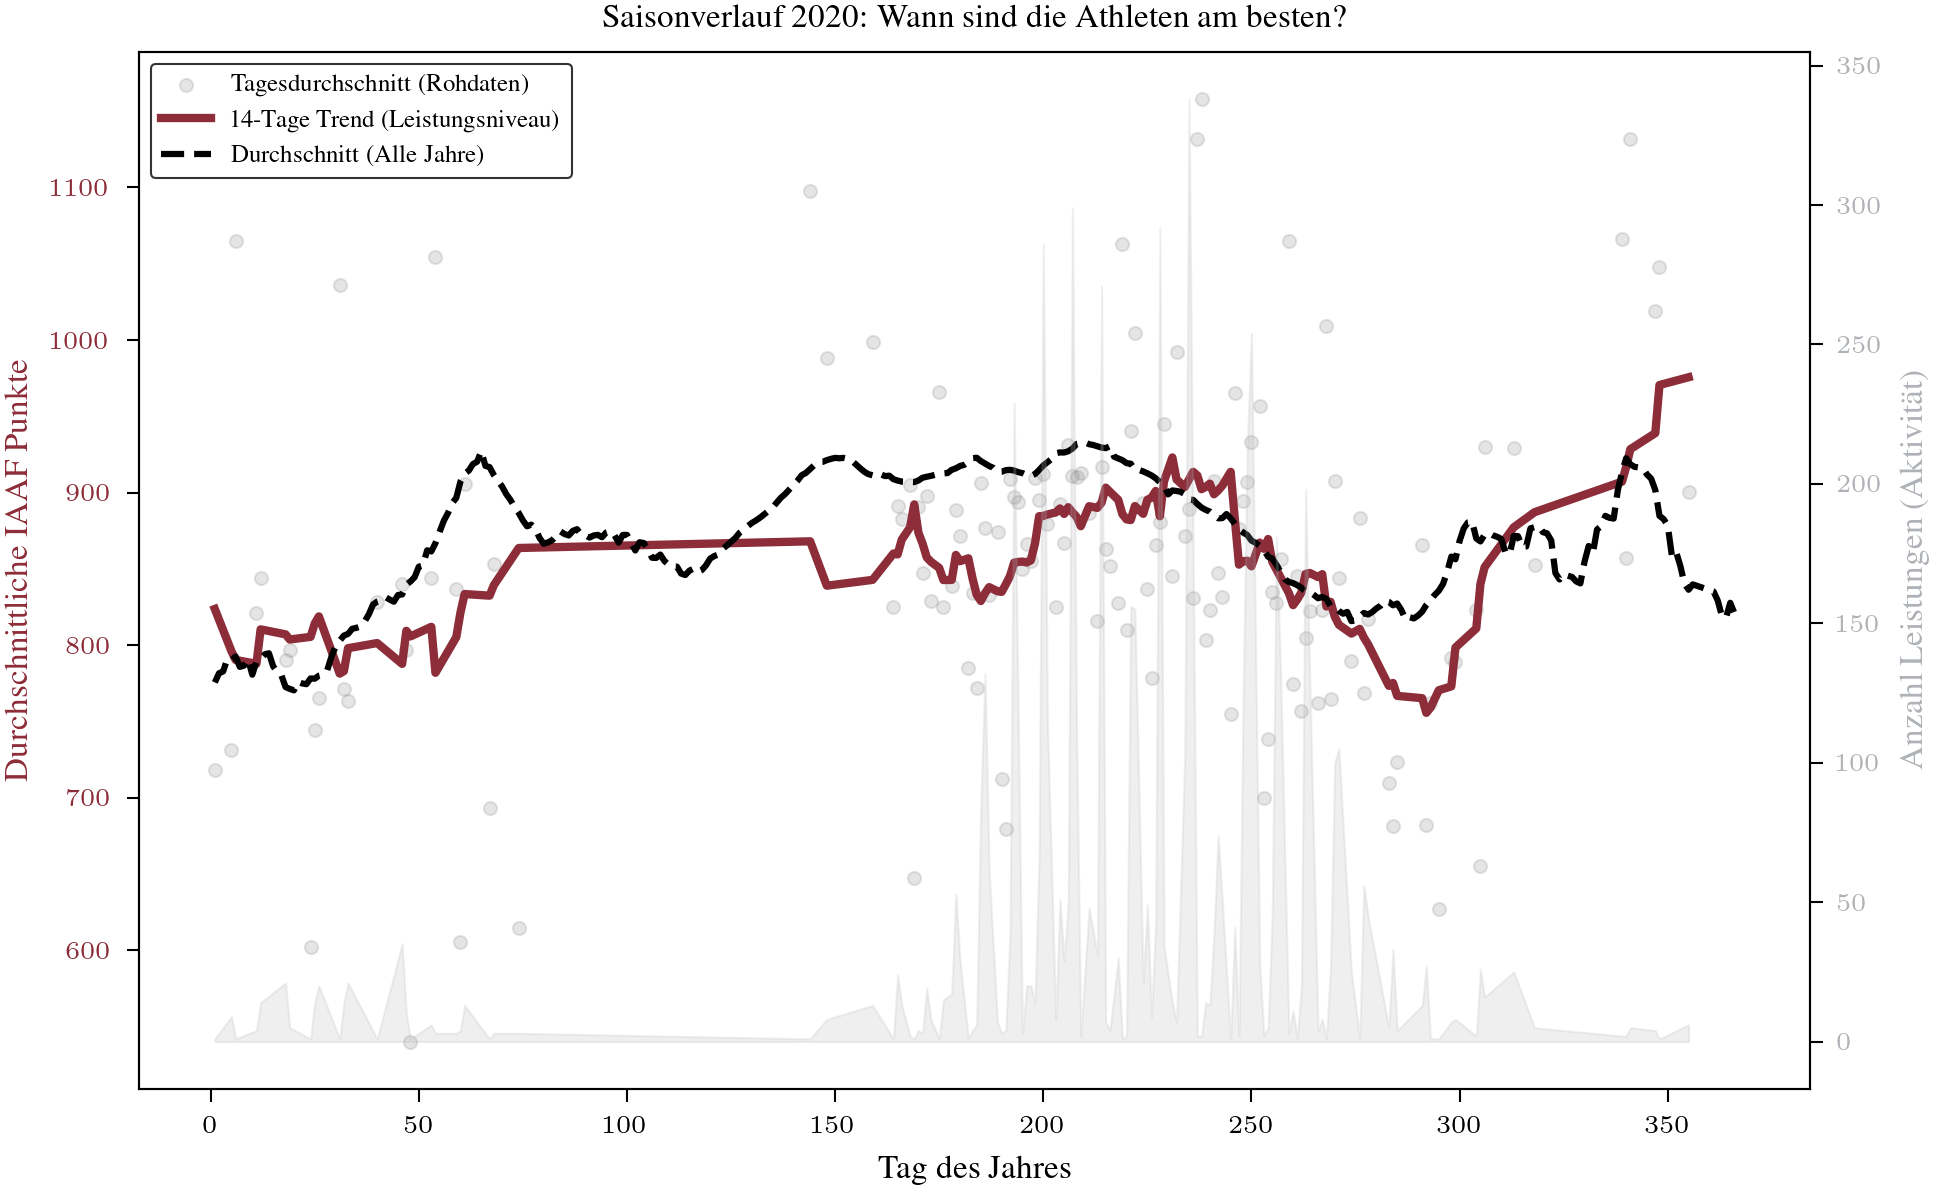

In [6]:
target_year = 2020
df_year = df_clean[df_clean['jahr'] == target_year]

# Aggregate by Day of Year
# We calculate mean score and the count of competitions per day
daily_stats = df_year.groupby('day_of_year')['iaaf_score'].agg(['mean', 'count'])

# Rolling Average to smooth out weekend spikes (7-day window)
daily_stats['smoothed_mean'] = daily_stats['mean'].rolling(window=14, center=True, min_periods=1).mean()

# Calculate global mean across ALL years for comparison
global_stats = df_clean.groupby('day_of_year')['iaaf_score'].mean()
global_smoothed = global_stats.rolling(window=14, center=True, min_periods=1).mean()

# Plotting
with plt.rc_context(plt.increase_figsize(2)):
    fig, ax1 = plt.subplots()

    # Plot Mean Score
    ax1.scatter(daily_stats.index, daily_stats['mean'], alpha=0.2, color='gray', s=10, label='Tagesdurchschnitt (Rohdaten)')
    ax1.plot(daily_stats.index, daily_stats['smoothed_mean'], color=rgb.tue_red, linewidth=2, label='14-Tage Trend (Leistungsniveau)')
    
    # Add Global Mean
    ax1.plot(global_smoothed.index, global_smoothed, color='black', linestyle='--', linewidth=1.5, label='Durchschnitt (Alle Jahre)')

    ax1.set_xlabel('Tag des Jahres')
    ax1.set_ylabel('Durchschnittliche IAAF Punkte', color=rgb.tue_red)
    ax1.tick_params(axis='y', labelcolor=rgb.tue_red)

    # Create a twin axis to show the density of competitions (Number of results)
    ax2 = ax1.twinx()
    ax2.fill_between(daily_stats.index, daily_stats['count'], color=rgb.tue_gray, alpha=0.2, label='Anzahl Leistungen')
    ax2.set_ylabel('Anzahl Leistungen (Aktivität)', color=rgb.tue_gray)
    ax2.tick_params(axis='y', labelcolor=rgb.tue_gray)

    # Annotations for Seasons
    plt.title(f'Saisonverlauf {target_year}: Wann sind die Athleten am besten?')
    ax1.legend()

    plt.show()

## 3. Multi-Year Analysis (The COVID-19 Impact)
We overlay all years to see the general pattern, but we **highlight 2020** to visualize the disruption caused by the pandemic.

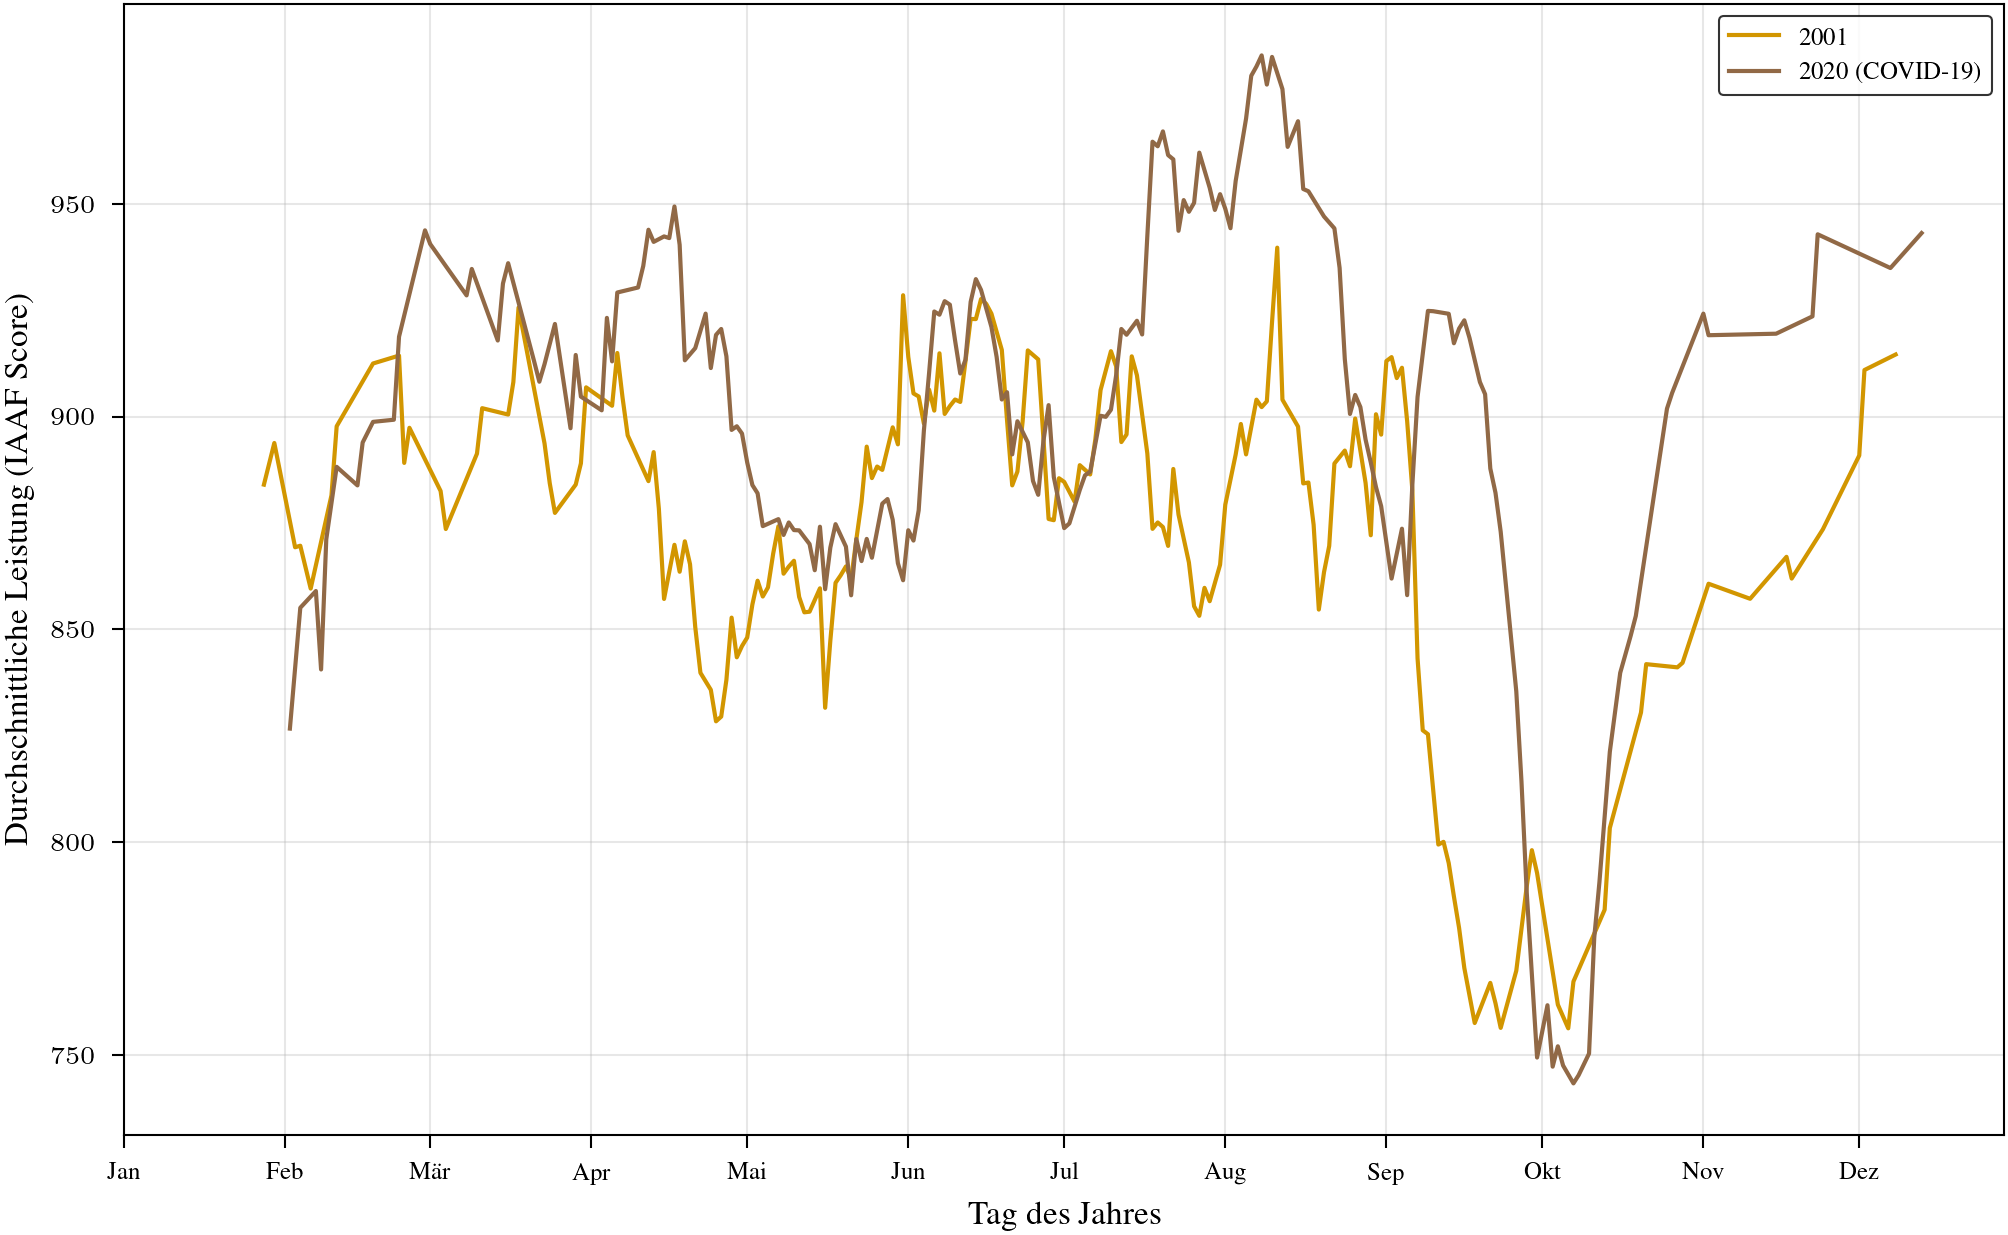

In [8]:
# Group by Day of Year across ALL years
global_stats = df_clean.groupby('day_of_year')['iaaf_score'].median()
global_smoothed = global_stats.rolling(window=14, center=True).mean()

lockdowns = [
    # Lockdown 1: Mid-March to Early May 2020
    (pd.to_datetime('2020-03-15').dayofyear, pd.to_datetime('2020-05-05').dayofyear),
    # Lockdown 2 ("Light" + "Bundesnotbremse"): Nov 2020 to ~June 2021
    (pd.to_datetime('2020-11-02').dayofyear, 365)
]

with plt.rc_context(plt.bundles.icml2024(column="full")):

    years = df_clean['jahr'].unique()
    for y in years:
        y_data = df_clean[df_clean['jahr'] == y].groupby('day_of_year')['iaaf_score'].median().rolling(window=14, center=True).mean()
        
        # Logic to highlight 2020
        if y == 2024:
            plt.plot(y_data.index, y_data, color=rgb.tue_orange, alpha=1.0, linewidth=1.0, label='2001', zorder=10)
        # elif y == 2024:
        #     plt.plot(y_data.index, y_data, color=rgb.tue_green, alpha=1.0, linewidth=1.0, label='2024', zorder=10)
        # elif y == 2020:
        #     plt.plot(y_data.index, y_data, color=rgb.tue_blue, alpha=1.0, linewidth=1.0, label='2020 (COVID-19)', zorder=10)
        elif y == 2025:
            plt.plot(y_data.index, y_data, color=rgb.tue_brown, alpha=1.0, linewidth=1.0, label='2020 (COVID-19)', zorder=10)
        # else:
        #     # plt.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=((y - 2001) / (2024 - 2001)) / 2, linewidth=1)
        #     plt.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=0.15, linewidth=1)

    # Plot the global average
    # plt.plot(global_smoothed.index, global_smoothed, color=rgb.tue_red, linewidth=1.5, label='Durchschnitt (2001-2024)', zorder=5)

    # for start, end in lockdowns:
    #     plt.axvspan(start, end, color=rgb.tue_red, alpha=0.15, label='Lockdown (DE)')


    # plt.title('Der "Herzschlag" der Saison: Der Einbruch durch COVID-19 (2020)')
    plt.xlabel('Tag des Jahres')
    plt.ylabel('Durchschnittliche Leistung (IAAF Score)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # X-Axis formatting to Months
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
    plt.xticks(month_starts, month_names)

    # plt.savefig('seasonal_performance_youth')
    plt.show()


### **Observations (2020)**
The 2020 line (blue) clearly shows:
1.  **Normal Indoor Season**: The year started normally (Jan-Feb).
2.  **Lockdown Gap**: A massive gap in March/April/May where competitions ceased.
3.  **Late Start**: The outdoor season started much later (July/August) than usual.

(153015, 14)
(147047, 14)
Index([  1,   5,   6,  11,  12,  18,  19,  24,  25,  26,
       ...
       305, 306, 313, 318, 339, 340, 341, 347, 348, 355],
      dtype='int32', name='day_of_year', length=144)
day_of_year
1       1
5       9
6       1
11      4
12     14
       ..
340     2
341     5
347     4
348     1
355     6
Name: count, Length: 144, dtype: int64


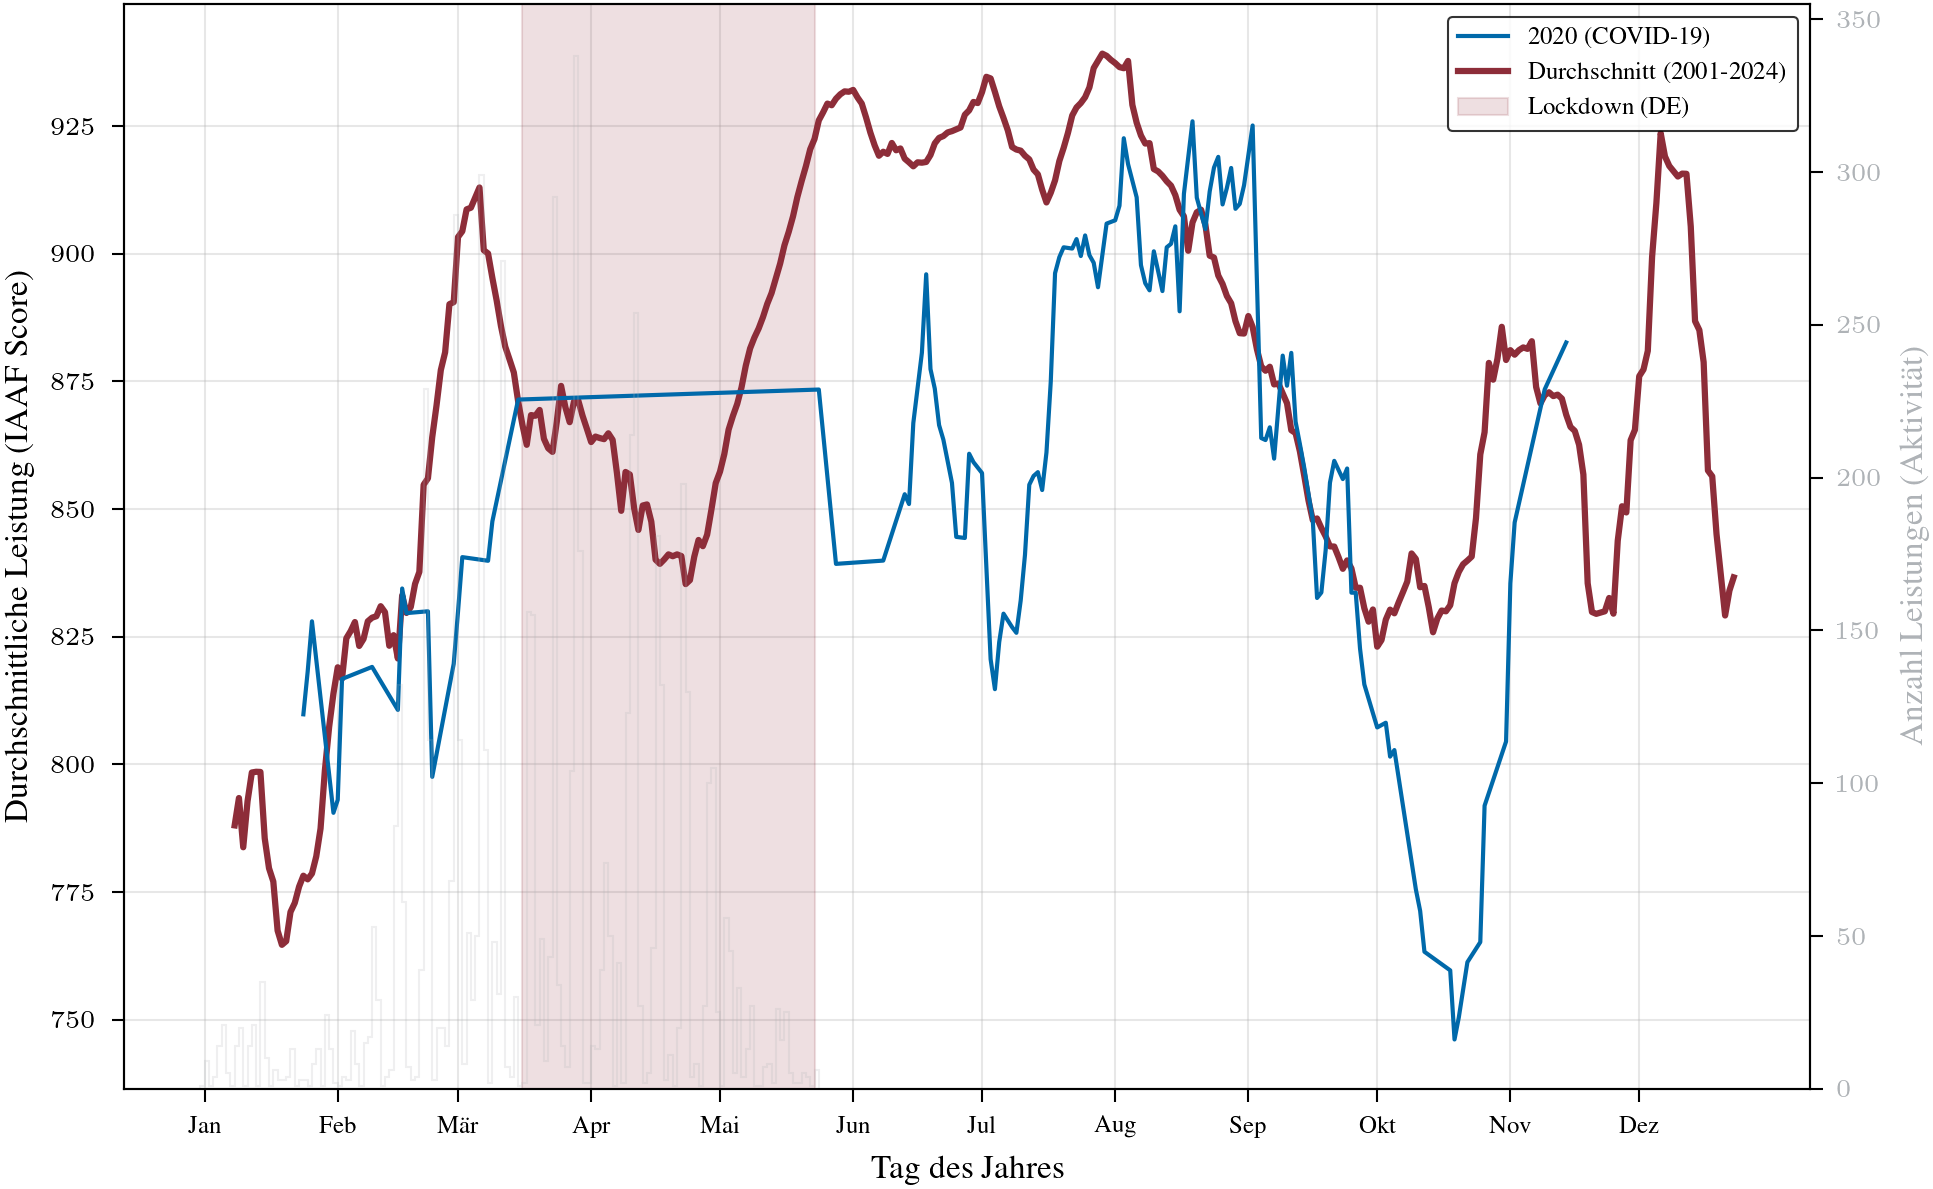

In [8]:
# Group by Day of Year across ALL years
print(df_clean.shape)
df_germany = df_clean[~df_clean['ort'].str.contains(r'/[A-Z]{3}', regex=True)].copy()
print(df_germany.shape)
global_stats = df_germany.groupby('day_of_year')['iaaf_score'].median()
global_smoothed = global_stats.rolling(window=14, center=True).mean()

daily_stats = df_germany[df_germany['jahr'] == 2020].groupby('day_of_year')['iaaf_score'].agg(['median', 'count'])


lockdowns = [
    # Lockdown 1: Mid-March to Early May 2020
    (pd.to_datetime('2020-03-15').dayofyear, pd.to_datetime('2020-05-22').dayofyear),
    # Lockdown 2 ("Light" + "Bundesnotbremse"): Nov 2020 to ~June 2021
    # (pd.to_datetime('2020-11-02').dayofyear, 365)
]

with plt.rc_context(plt.increase_figsize(2)):
    fig, ax1 = plt.subplots()

    years = df_germany['jahr'].unique()
    for y in years:
        y_data = df_germany[df_germany['jahr'] == y].groupby('day_of_year')['iaaf_score'].median().rolling(window=14, center=True).mean()
        
        # Logic to highlight 2020
        if y == 2020:
            ax1.plot(y_data.index, y_data, color=rgb.tue_blue, alpha=1.0, linewidth=1.0, label='2020 (COVID-19)', zorder=10)
        # elif y == 2024:
        #     plt.plot(y_data.index, y_data, color=rgb.tue_green, alpha=1.0, linewidth=1.0, label='2024', zorder=10)
        # elif y == 2001:
        #     plt.plot(y_data.index, y_data, color=rgb.tue_orange, alpha=1.0, linewidth=1.0, label='2001', zorder=10)
        # else:
        #     ax1.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=((y - 2001) / (2024 - 2001)) / 2, linewidth=1)
        #     # plt.plot(y_data.index, y_data, color=rgb.tue_gray, alpha=0.15, linewidth=1)

    # Plot the global average
    ax1.plot(global_smoothed.index, global_smoothed, color=rgb.tue_red, linewidth=1.5, label='Durchschnitt (2001-2024)', zorder=5)
    for start, end in lockdowns:
        ax1.axvspan(start, end, color=rgb.tue_red, alpha=0.15, label='Lockdown (DE)')


    # plt.title('Der "Herzschlag" der Saison: Der Einbruch durch COVID-19 (2020)')
    ax1.set_xlabel('Tag des Jahres')
    ax1.set_ylabel('Durchschnittliche Leistung (IAAF Score)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    print(daily_stats.index)
    print(daily_stats['count'])
    ax2.stairs(daily_stats['count'], color=rgb.tue_gray, alpha=0.2, label='Anzahl Leistungen')
    # ax2.hist(daily_stats['count'], bins=50, color=rgb.tue_gray, alpha=0.2, label='Anzahl Leistungen')
    ax2.set_ylabel('Anzahl Leistungen (Aktivität)', color=rgb.tue_gray)
    ax2.tick_params(axis='y', labelcolor=rgb.tue_gray)

    # X-Axis formatting to Months
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_names = ['Jan', 'Feb', 'Mär', 'Apr', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez']
    ax1.set_xticks(month_starts)
    ax1.set_xticklabels(month_names)

    plt.savefig('seasonal_performance_youth')
    plt.show()


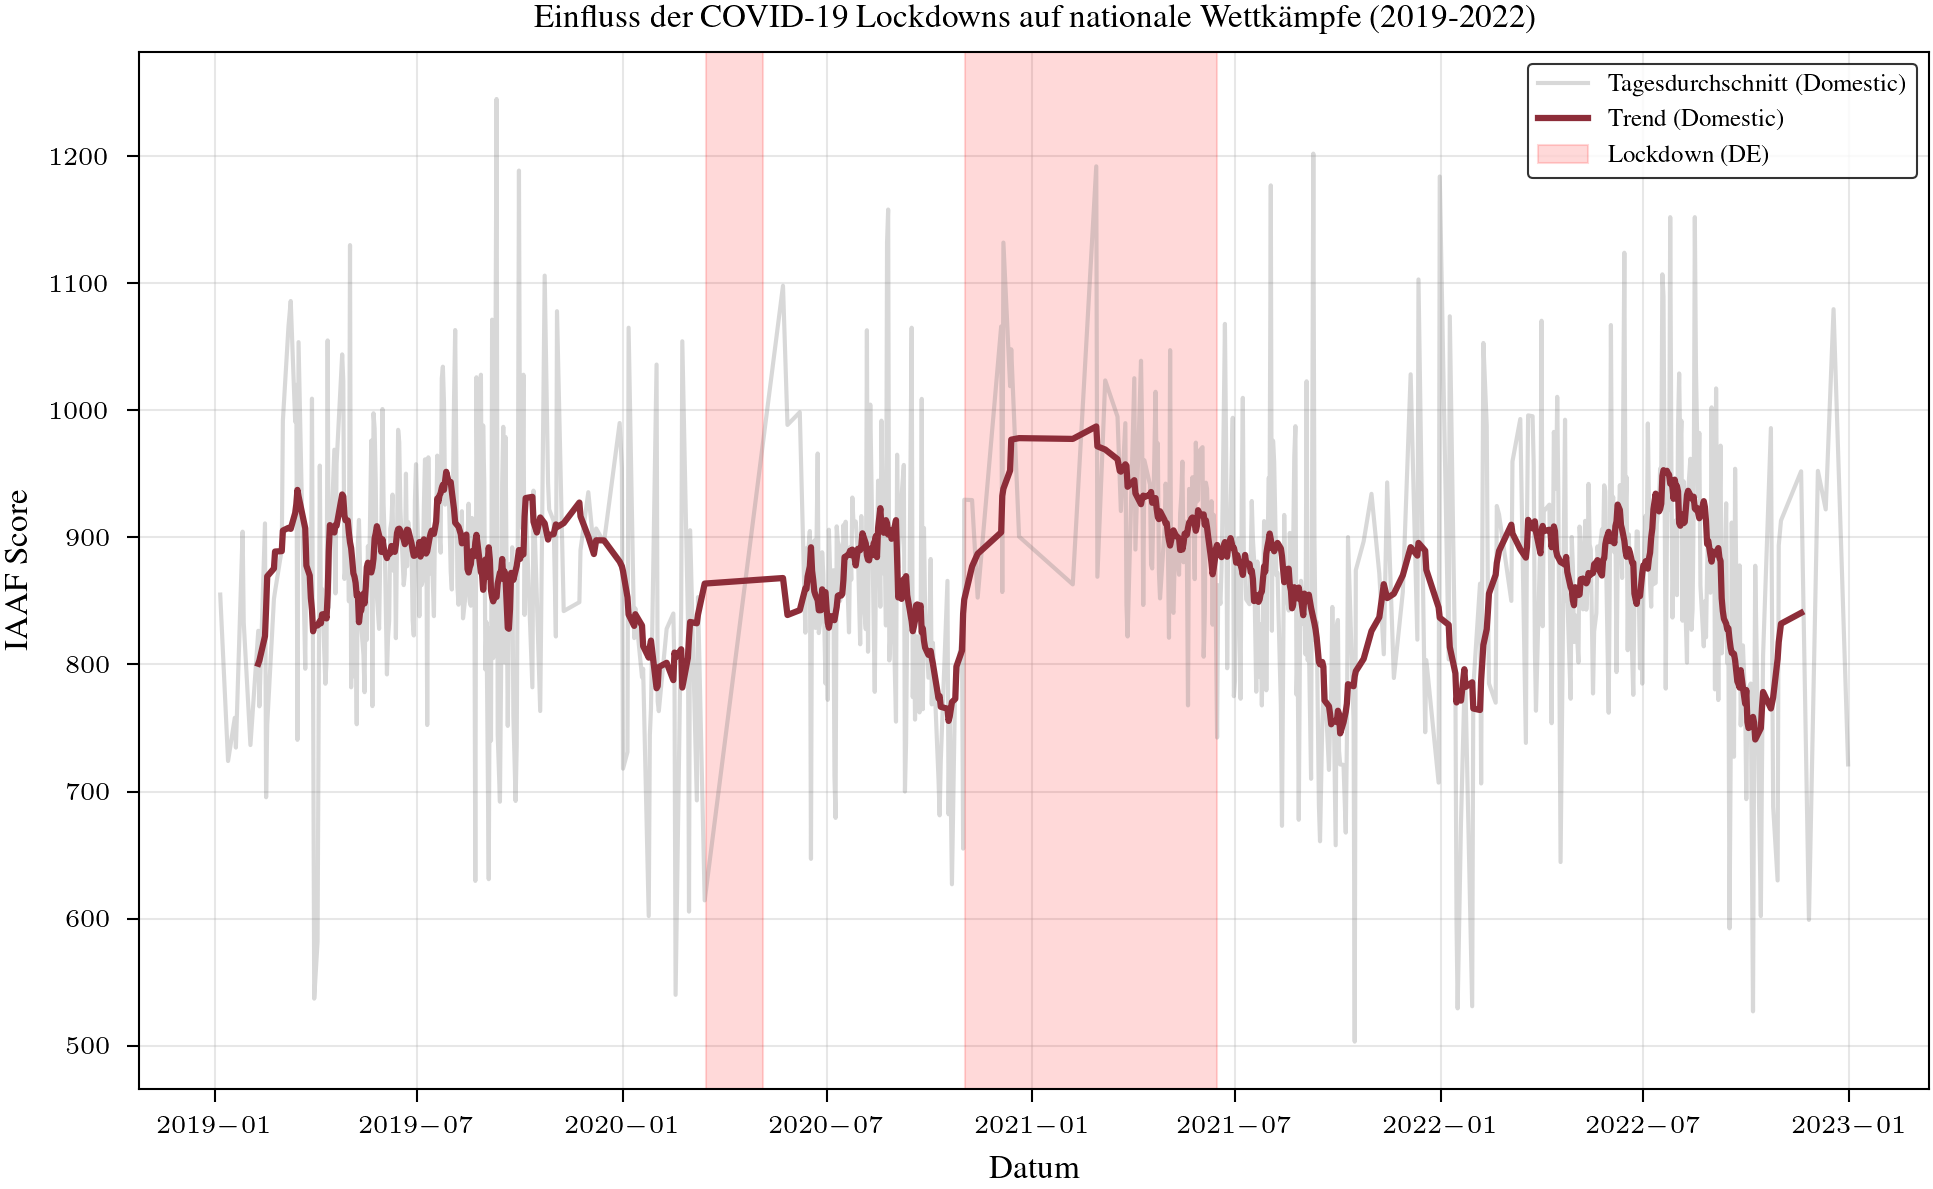

In [9]:
# 1. Filter for Domestic (German) Events
# Exclude locations matching "/XXX" (e.g. London/GBR)
df_germany = df_clean[~df_clean['ort'].str.contains(r'/[A-Z]{3}', regex=True)].copy()

# 2. Define Lockdown Periods (approximate dates for Germany)
lockdowns = [
    # Lockdown 1: Mid-March to Early May 2020
    (pd.to_datetime('2020-03-15'), pd.to_datetime('2020-05-05')),
    # Lockdown 2 ("Light" + "Bundesnotbremse"): Nov 2020 to ~June 2021
    (pd.to_datetime('2020-11-02'), pd.to_datetime('2021-06-15'))
]

# 3. Prepare Time Series Data (Daily Mean)
# We focus on the timeline 2019 - 2022 to see the impact
df_focus = df_germany[df_germany['jahr'].between(2019, 2022)]
daily_trend = df_focus.groupby('parsed_date')['iaaf_score'].mean()

# Smooth the data for better visualization
daily_trend_smoothed = daily_trend.rolling(window=14, center=True).mean()

# 4. Plotting
with plt.rc_context(plt.increase_figsize(2)):
    fig, ax = plt.subplots()
    
    # Plot the performance trend
    ax.plot(daily_trend.index, daily_trend, color='gray', alpha=0.3, label='Tagesdurchschnitt (Domestic)')
    ax.plot(daily_trend_smoothed.index, daily_trend_smoothed, color=rgb.tue_red, linewidth=1.5, label='Trend (Domestic)')

    # Add Lockdown Areas
    for start, end in lockdowns:
        ax.axvspan(start, end, color='red', alpha=0.15, label='Lockdown (DE)')

    # Formatting
    plt.title('Einfluss der COVID-19 Lockdowns auf nationale Wettkämpfe (2019-2022)')
    plt.ylabel('IAAF Score')
    plt.xlabel('Datum')
    
    # Handle duplicate labels in legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    
    plt.grid(True, alpha=0.3)
    plt.show()

### **Finding Exact COVID-19 Competition Gaps (2020)**
We identify periods in 2020 with zero recorded competition results to precisely locate the lockdowns.

In [10]:
# Filter for 2020
df_2020 = df_clean[df_clean['jahr'] == 2020]
df_2020 = df_2020[~df_2020['ort'].str.contains(r'/[A-Z]{3}', regex=True)].copy()

# Create a full date range for the year 2020
all_dates_2020 = pd.date_range(start='2020-01-01', end='2020-12-31')

# Count competitions per day
daily_counts = df_2020.groupby('parsed_date').size().reindex(all_dates_2020, fill_value=0)

# Find continuous blocks of days with zero competitions
gaps = daily_counts[daily_counts == 0].index
if len(gaps) > 0:
    ranges = []
    start = gaps[0]
    for i in range(1, len(gaps)):
        if (gaps[i] - gaps[i-1]).days > 1:
            ranges.append((start, gaps[i-1]))
            start = gaps[i]
    ranges.append((start, gaps[-1]))
    
    print("Found the following gaps in 2020:")
    for s, e in ranges:
        if (e-s).days > 7: # Only show significant gaps (longer than a week)
            print(f"- {s.strftime('%d.%m.%Y')} to {e.strftime('%d.%m.%Y')} ({(e-s).days + 1} days)")
else:
    print("No gaps found in 2020.")

Found the following gaps in 2020:
- 15.03.2020 to 22.05.2020 (69 days)
- 28.05.2020 to 06.06.2020 (10 days)
- 14.11.2020 to 03.12.2020 (20 days)
- 21.12.2020 to 31.12.2020 (11 days)


## 4. Performance Statistics
Counting the number of performances per year, discipline, gender, and age group.

In [11]:
# Group by year, discipline, gender, and age group
performance_counts = df.groupby(['jahr', 'disziplin', 'geschlecht', 'altersklasse']).size().reset_index(name='anzahl_leistungen')

# Display the counts (first 20 for overview)
print("Total unique combinations:", len(performance_counts))
performance_counts_df = performance_counts.sort_values(by=['jahr', 'anzahl_leistungen'], ascending=[True, False])
performance_counts_df.to_csv('performance_counts.csv', index=False)

Total unique combinations: 3487


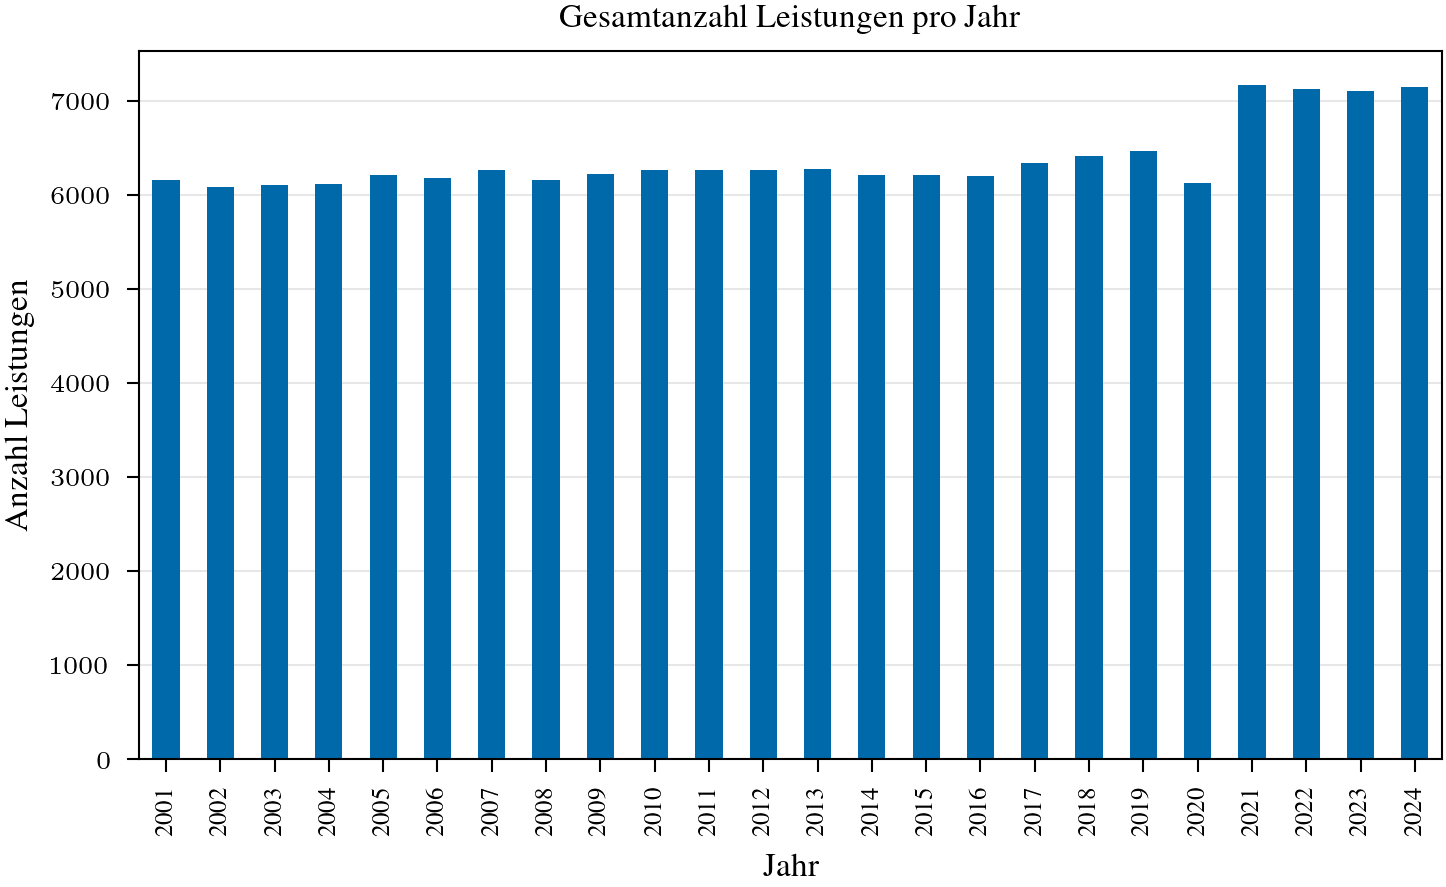

In [12]:
# Plot total performances per year
yearly_totals = df.groupby('jahr').size()

with plt.rc_context(plt.increase_figsize(1.5)):
    plt.figure()
    yearly_totals.plot(kind='bar', color=rgb.tue_blue)
    plt.title('Gesamtanzahl Leistungen pro Jahr')
    plt.xlabel('Jahr')
    plt.ylabel('Anzahl Leistungen')
    plt.grid(axis='y', alpha=0.3)
    plt.show()